## Generate dataset for multiplication only

- a from [0, 1000]
- b from [0, 1000]

Format is JSON:
```
[
    {
       input: [a, b],
       target: a * b
    }
    ...
    ...
]
```

In [4]:
import random
import json

dataset = []

for _ in range(20_000):
    a = random.randint(0, 100)
    b = random.randint(0, 100)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

# for _ in range(25_000):
#     a = random.randint(0, 1000)
#     b = random.randint(0, 1000)
#     target = a * b
#     data = {
#         'input': { 'a': str(a), 'b': str(b) },
#         'target': str(target)
#     }
#     dataset.append(data)

print(json.dumps(dataset[:5], indent=4))
print(f"completed dataset creation of size {len(dataset)}....")

[
    {
        "input": {
            "a": "66",
            "b": "79"
        },
        "target": "5214"
    },
    {
        "input": {
            "a": "59",
            "b": "84"
        },
        "target": "4956"
    },
    {
        "input": {
            "a": "65",
            "b": "70"
        },
        "target": "4550"
    },
    {
        "input": {
            "a": "41",
            "b": "57"
        },
        "target": "2337"
    },
    {
        "input": {
            "a": "87",
            "b": "99"
        },
        "target": "8613"
    }
]
completed dataset creation of size 20000....


In [5]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.optim as optim
from train_util import Trainer
from tokenizer import DigitTokenizer
from torch.optim.lr_scheduler import LambdaLR

DATA_DIR = "/teamspace/studios/this_studio/SAIR-competition-modular-math/data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

rand_seed = 42

batch_size = 64
max_seq_len = 32 # very small context window...
d_model = 1024

Training on device: cuda


In [6]:
# Multiplication only for now ...
tokenizer = DigitTokenizer()
eq_id = tokenizer.char_to_int["="]
eos_id = tokenizer.char_to_int["<eos>"]
pad_id = tokenizer.char_to_int["<pad>"]
tokenized_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']

    a_token_id = tokenizer.encode(str_a)
    b_token_id = tokenizer.encode(str_b)
    tgt_token_id = tokenizer.encode(str_tgt)
    # KEY DECISION: reversing each input token so QKt aligns during math operations digit wise, from small to big
    a_token_id.reverse(), b_token_id.reverse(), tgt_token_id.reverse()
    tgt_token_id.append(eos_id)

    if len(a_token_id) < max_seq_len:
        a_token_id = a_token_id + [pad_id] * (max_seq_len - len(a_token_id))
    else:
        a_token_id = a_token_id[:max_seq_len]
    
    if len(b_token_id) < max_seq_len:
        b_token_id = b_token_id + [pad_id] * (max_seq_len - len(b_token_id))
    else:
        b_token_id = b_token_id[:max_seq_len]
    
    if len(tgt_token_id) < max_seq_len:
        tgt_token_id = tgt_token_id + [pad_id] * (max_seq_len - len(tgt_token_id))
    else:
        tgt_token_id = tgt_token_id[:max_seq_len]

    tokenized_input.append([a_token_id, b_token_id, tgt_token_id])


dataset_tensor = torch.tensor(tokenized_input, dtype=torch.long)

print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(dataset_tensor[:3])

Dataset securely loaded in-memory. Matrix shape: torch.Size([20000, 3, 32])
The <eos> token id is: 14
tensor([[[ 6,  6, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 9,  7, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 4,  1,  2,  5, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13]],

        [[ 9,  5, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 4,  8, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 6,  5,  9,  4, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
          13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13]],



In [7]:
train_loader, val_loader, test_loader = Trainer.dataset_tensor_to_loader(
    dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = batch_size,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Val Loader:   {len(val_loader)} batches")
print(f"Test Loader:  {len(test_loader)} batches")

Train Loader: 250 batches
Val Loader:   32 batches
Test Loader:  32 batches


In [11]:
# This is dataset tensor for baseline standard GPT2 transformer ...
tokenized_standard_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']
    
    standard_str_input = f"{str_a}*{str_b}={str_tgt}"
    standard_encoded_input = tokenizer.encode(standard_str_input)
    standard_encoded_input.append(eos_id)
    
    if len(standard_encoded_input) < 64:
        standard_encoded_input = standard_encoded_input + [pad_id] * (64 - len(standard_encoded_input))
    else:
        standard_encoded_input = standard_encoded_input[:64]

    tokenized_standard_input.append(standard_encoded_input)


standard_dataset_tensor = torch.tensor(tokenized_standard_input, dtype=torch.long)

print(f"Standard dataset securely loaded in-memory. Matrix shape: {standard_dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(standard_dataset_tensor[:3])

Standard dataset securely loaded in-memory. Matrix shape: torch.Size([20000, 64])
The <eos> token id is: 14
tensor([[ 6,  6, 10,  7,  9, 12,  5,  2,  1,  4, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 5,  9, 10,  8,  4, 12,  4,  9,  5,  6, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 6,  5, 10,  7,  0, 12,  4,  5,  5,  0, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13]])


In [12]:
train_loader_std, val_loader_std, test_loader_std = Trainer.dataset_tensor_to_loader(
    standard_dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = 64,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader_std)} batches")
print(f"Val Loader:   {len(val_loader_std)} batches")
print(f"Test Loader:  {len(test_loader_std)} batches")

Train Loader: 250 batches
Val Loader:   32 batches
Test Loader:  32 batches


In [13]:
'''
Using standard GPT2 transformer model as baseline
'''
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,   
    n_embd=384,                       
    n_layer=6,                         
    n_head=6,                          
    n_ctx=64,                        
    bos_token_id=None,                 
    eos_token_id=tokenizer.char_to_int["<eos>"],
    pad_token_id=tokenizer.char_to_int["<pad>"]
)

baseline_model = GPT2LMHeadModel(config).to(device)

num_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params:,}")

Total Trainable Parameters: 11,046,912


In [14]:
'''
Training loop for baseline model...
'''
eq_id = tokenizer.char_to_int["="]
eos_id = tokenizer.char_to_int["<eos>"]
pad_id = tokenizer.char_to_int["<pad>"]
vocab_size = tokenizer.vocab_size
std_trainer = Trainer(device=device)
std_optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=1e-4, # 1e-3 for batch 64, 3e-3 for batch 256
    betas=(0.9, 0.99),
    weight_decay=0.1,
)
std_loss_fct = nn.CrossEntropyLoss(
    reduction="none",
    ignore_index=pad_id
)
warmup_steps = 400 # 100 for batch 64, 400 for batch 256

In [12]:
'''
Loading standard model checkpoint ....
'''
std_trainer.load_checkpoint("baseline_gpt2_epoch_55.pt", baseline_model, std_optimizer)

📂 Loading checkpoint: /teamspace/studios/this_studio/SAIR-competition-modular-math/checkpoints/baseline_gpt2_epoch_55.pt...
Successfully restored state from baseline_gpt2_epoch_55.pt (Epochs completed: 56)


In [15]:
def gen_loss_mask(targets: torch.Tensor):
    batch_size, seq_len = targets.shape
    eq_indices = (targets == eq_id).int().argmax(dim=-1).reshape(batch_size, 1)
    eos_indices = (targets == eos_id).int().argmax(dim=-1).reshape(batch_size, 1)
    pos_grid = torch.arange(seq_len).reshape(1, seq_len).to(device)
    loss_mask = ((pos_grid > eq_indices) & (pos_grid <= eos_indices)).view(-1)
    
    return loss_mask

def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor, loss_mask: torch.Tensor):
    batch_size, seq_len = targets.shape
    
    loss_mask = loss_mask.reshape(batch_size, seq_len)
    predictions = logits.argmax(dim=-1)
    correct_tokens = (predictions == targets)
    valid_tokens = correct_tokens | (~loss_mask)
    exact_sequence_match = valid_tokens.all(dim=-1)
    
    return exact_sequence_match.float().mean()

def lr_lambda(current_step):
    current_step = 1 if current_step == 0 else current_step
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    return 1.0

std_scheduler = LambdaLR(std_optimizer, lr_lambda=lr_lambda)

def train_model(num_epochs_to_add: int):
    start_epoch = len(std_trainer.train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    for epoch in range(start_epoch, target_epoch):
        baseline_model.train()
        total_train_loss = 0.0
        total_val_loss = 0.0
        total_train_accuracy = 0.0
        total_val_accuracy = 0.0

        for batch_sequences in tqdm(train_loader_std, desc=f"Epoch {epoch+1} Training"):
            batch_sequences = batch_sequences.to(device)
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()

            # Generating attention mask for input and loss mask for output ...
            attention_mask = (inputs != pad_id).long()
            loss_mask = gen_loss_mask(targets)
            logits = baseline_model(inputs, attention_mask=attention_mask).logits
            loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
            loss = loss[loss_mask].mean()
            accuracy = compute_accuracy(logits, targets, loss_mask)

            
            std_optimizer.zero_grad()
            loss.backward()
            std_optimizer.step()
            std_scheduler.step()
            total_train_loss += loss.item()
            total_train_accuracy += accuracy.item()

        baseline_model.eval()
        with torch.no_grad():
            for batch_sequences in tqdm(val_loader_std, desc=f"Epoch {epoch+1} Validation"):
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()

                # Need to also apply attention mask and loss mask ...
                attention_mask = (inputs != pad_id).long()
                loss_mask = gen_loss_mask(targets)
                logits = baseline_model(inputs, attention_mask=attention_mask).logits
                loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss = loss[loss_mask].mean()
                accuracy = compute_accuracy(logits, targets, loss_mask)
                
                total_val_loss += loss.item()
                total_val_accuracy += accuracy.item()

        avg_train_loss = total_train_loss / len(train_loader_std)
        avg_val_loss   = total_val_loss / len(val_loader_std)
        avg_train_accuracy = total_train_accuracy / len(train_loader_std)
        avg_val_accuracy   = total_val_accuracy / len(val_loader_std)
        std_trainer.add_loss_and_accuracy(avg_train_loss, avg_val_loss, avg_train_accuracy, avg_val_accuracy)

        std_trainer.plot_live_loss(
            current_epoch=epoch,
            total_target_epochs=target_epoch
        )

        if (epoch > 20) & (epoch % 5 == 0):
            std_trainer.save_checkpoint(f"batch_baseline_gpt2_epoch_{epoch}", baseline_model, std_optimizer)

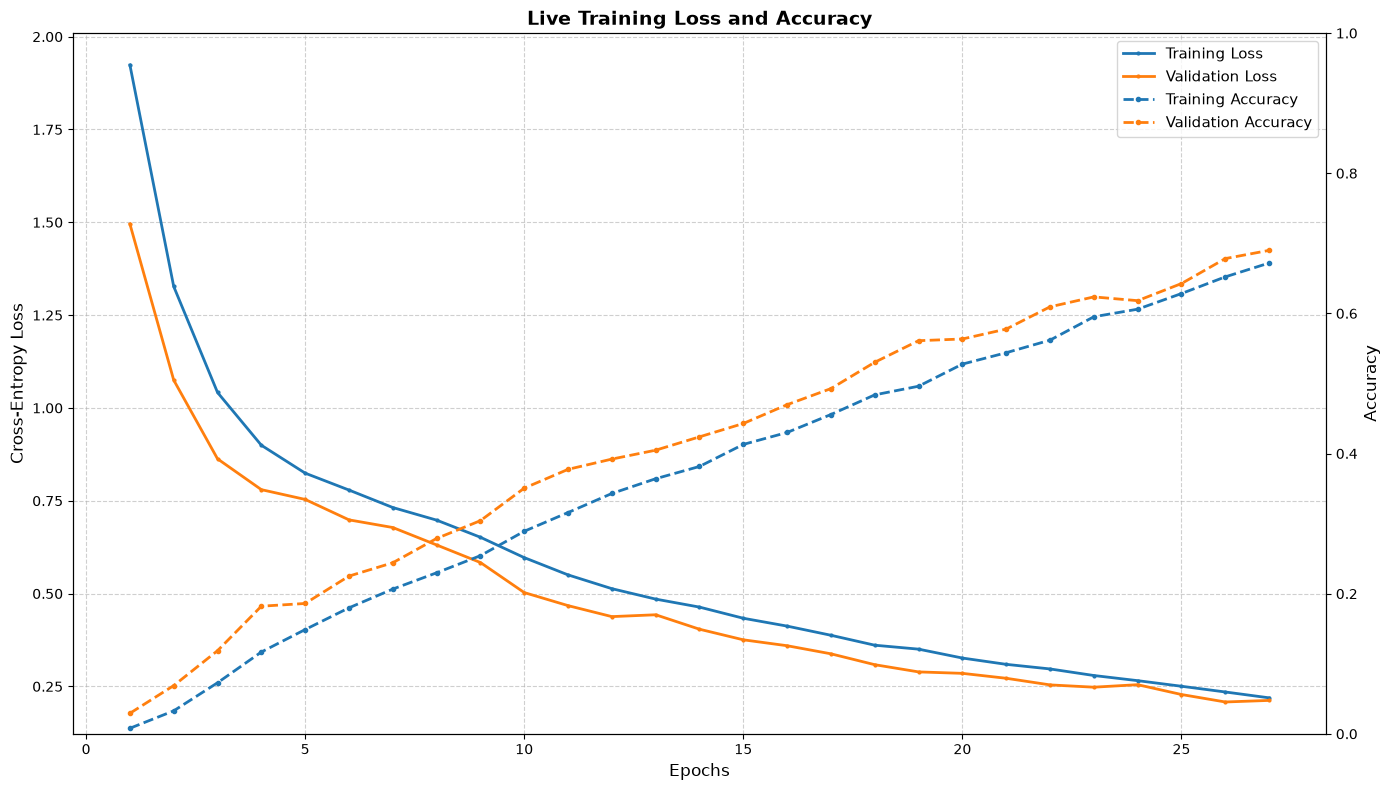

Latest Stats -> Epoch 26/30 | Train Loss: 0.2192 | Val Loss: 0.2123 | Train Acc: 0.6719 | Val Acc: 0.6899


Epoch 28 Training:   0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [17]:
train_model(20)

In [8]:
'''
Training loop for novel architecture for multiplication ...
'''
from select_attention import SelectAttention

pad_id = tokenizer.char_to_int["<pad>"]
vocab_size = tokenizer.vocab_size
trainer = Trainer(device=device)
model = SelectAttention(
    d_model=d_model,
    num_heads=8,
    max_seq_len=max_seq_len,
    vocab_size=vocab_size
)
model = model.to(device)
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.1,
)
loss_fct = nn.CrossEntropyLoss(
    ignore_index=pad_id
)
warmup_steps = 100

print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{num_params:,}")

SelectAttention(
  (rope): RoPE()
  (embedding): Embedding(16, 1024)
  (pre_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  (q_linear): Linear(in_features=1024, out_features=1024, bias=False)
  (k_linear): Linear(in_features=1024, out_features=1024, bias=False)
  (ffn): Sequential(
    (0): Linear(in_features=256, out_features=2048, bias=False)
    (1): SiLU()
    (2): Linear(in_features=2048, out_features=256, bias=False)
    (3): SiLU()
    (4): Linear(in_features=256, out_features=32, bias=False)
  )
  (final_layernorm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (output_linear): Linear(in_features=32, out_features=16, bias=False)
)
3,172,928


In [9]:
def lr_lambda(current_step):
    current_step = 1 if current_step == 0 else current_step
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    return 1.0

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor):
    batch_size, seq_len = targets.shape
    predictions = logits.argmax(dim=-1)
    corrects = (predictions == targets) | (targets == pad_id)
    accuracy = corrects.all(dim=-1)

    return accuracy.float().mean()

def train_model(num_epochs_to_add: int):
    start_epoch = len(trainer.train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    for epoch in range(start_epoch, target_epoch):
        model.train()
        total_train_loss = 0.0
        total_val_loss = 0.0
        total_train_accuracy = 0.0
        total_val_accuracy = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch} Training"):
            batch = batch.to(device)
            a, b, tgt = batch.unbind(dim=1)
            logits = model(a, b)
            train_loss = loss_fct(logits.reshape(-1, vocab_size), tgt.reshape(-1))
            train_accuracy = compute_accuracy(logits, tgt)

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()
            scheduler.step()
            total_train_loss += train_loss.item()
            total_train_accuracy += train_accuracy.item()

        model.eval()
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch} Validation"):
                batch = batch.to(device)
                a, b, tgt = batch.unbind(dim=1)
                logits = model(a, b)
                val_loss = loss_fct(logits.reshape(-1, vocab_size), tgt.reshape(-1))
                val_accuracy = compute_accuracy(logits, tgt)

                total_val_loss += val_loss.item()
                total_val_accuracy += val_accuracy.item()
                
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss   = total_val_loss / len(val_loader)
        avg_train_accuracy = total_train_accuracy / len(train_loader)
        avg_val_accuracy   = total_val_accuracy / len(val_loader)
        trainer.add_loss_and_accuracy(avg_train_loss, avg_val_loss, avg_train_accuracy, avg_val_accuracy)

        trainer.plot_live_loss(
            current_epoch=epoch,
            total_target_epochs=target_epoch
        )

        if (epoch > 20) & (epoch % 5 == 0):
            trainer.save_checkpoint(f"select_attention_epoch_{epoch}", model, optimizer)

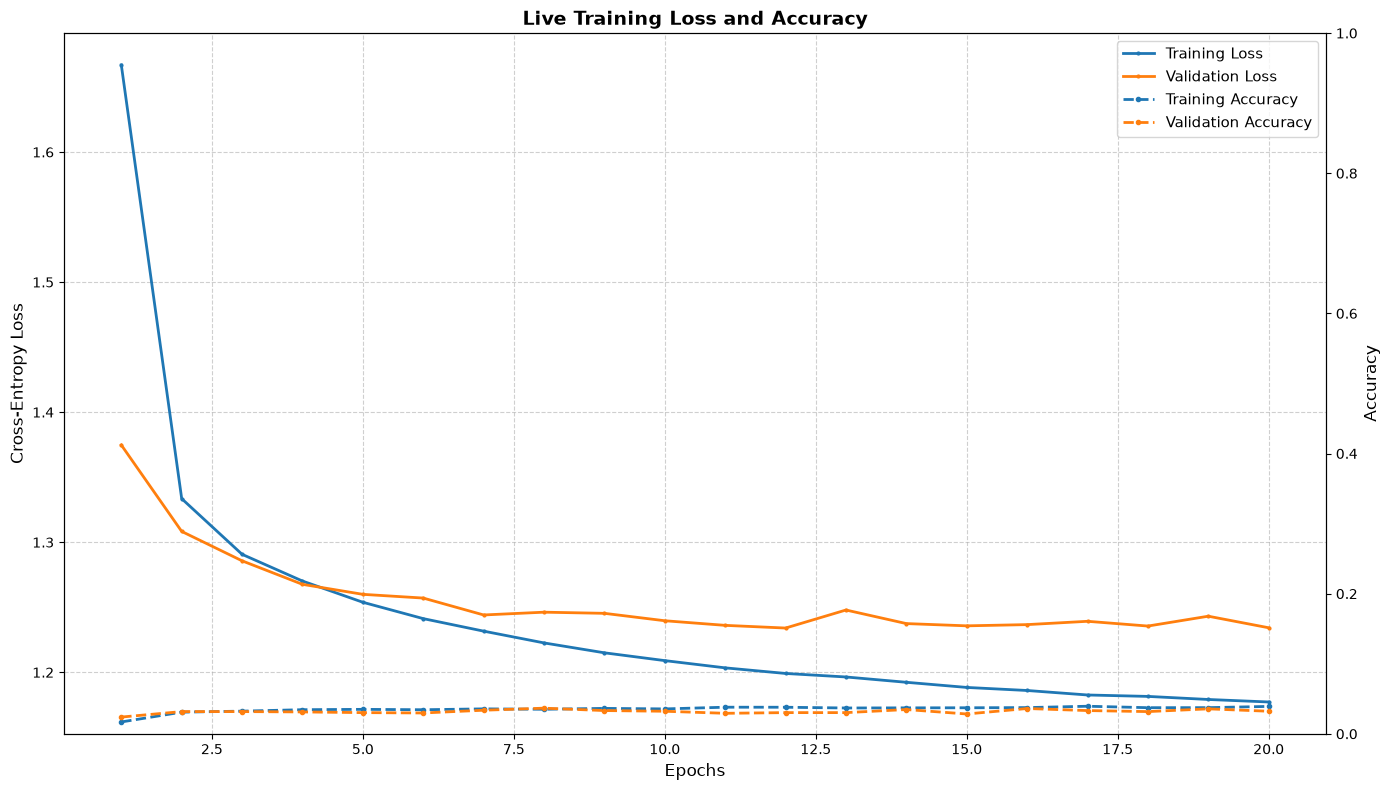

Latest Stats -> Epoch 19/20 | Train Loss: 1.1772 | Val Loss: 1.2343 | Train Acc: 0.0391 | Val Acc: 0.0322


In [10]:
train_model(20)